In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from sqlalchemy import create_engine

# Load from MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root@7900",
    database="finsight_db"
)

df = pd.read_sql("SELECT * FROM transactions", conn)
print(f"✅ Loaded {len(df)} rows")
print(f"Shape: {df.shape}")

C:\Users\bobad\AppData\Local\Temp\ipykernel_3912\94482012.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM transactions", conn)


✅ Loaded 284807 rows
Shape: (284807, 31)


In [3]:
print(f"Duplicates before: {df.duplicated().sum()}")

df = df.drop_duplicates()

print(f"Duplicates after: {df.duplicated().sum()}")
print(f"Rows remaining: {len(df)}")

Duplicates before: 1081
Duplicates after: 0
Rows remaining: 283726


In [4]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

# Check outliers on Amount column
outliers, lower, upper = detect_outliers_iqr(df, 'amount')

print(f"=== AMOUNT OUTLIER ANALYSIS ===")
print(f"Q1: {df['amount'].quantile(0.25)}")
print(f"Q3: {df['amount'].quantile(0.75)}")
print(f"IQR Lower Bound: {round(lower, 2)}")
print(f"IQR Upper Bound: {round(upper, 2)}")
print(f"Total Outliers Found: {len(outliers)}")
print(f"Outlier % : {round(len(outliers)/len(df)*100, 2)}%")

=== AMOUNT OUTLIER ANALYSIS ===
Q1: 5.6
Q3: 77.51
IQR Lower Bound: -102.27
IQR Upper Bound: 185.38
Total Outliers Found: 31685
Outlier % : 11.17%


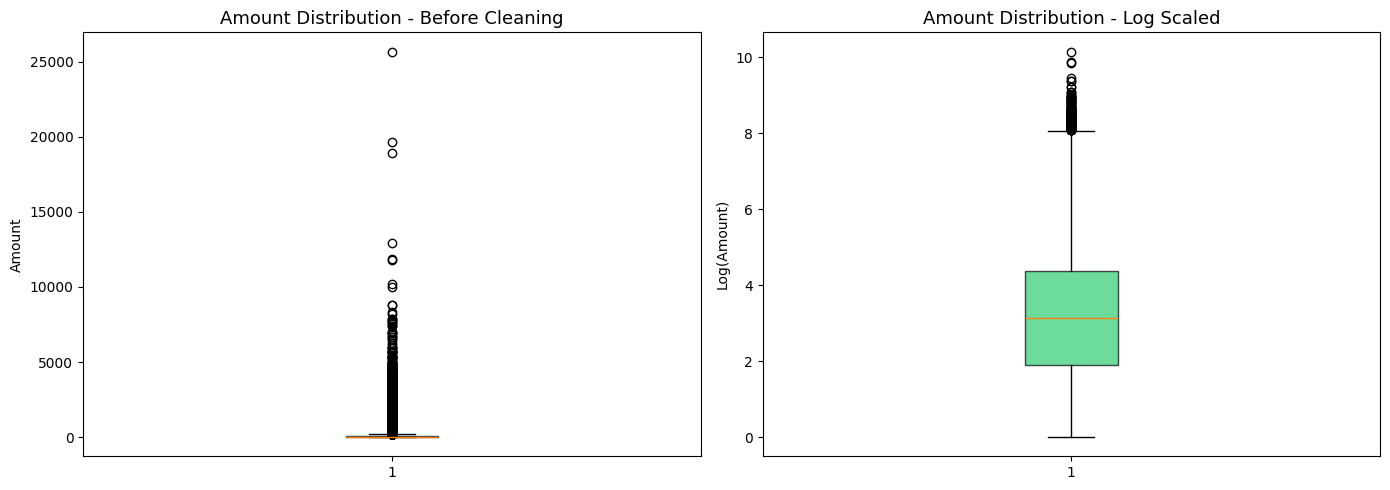

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].boxplot(df['amount'], patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[0].set_title('Amount Distribution - Before Cleaning', fontsize=13)
axes[0].set_ylabel('Amount')

# Log scale for better view
axes[1].boxplot(np.log1p(df['amount']), patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', alpha=0.7))
axes[1].set_title('Amount Distribution - Log Scaled', fontsize=13)
axes[1].set_ylabel('Log(Amount)')

plt.tight_layout()
plt.savefig('charts/outlier_boxplot.png', dpi=150)
plt.show()

In [7]:
# New meaningful columns
df['amount_log'] = np.log1p(df['amount'])

df['is_high_value'] = (df['amount'] > df['amount'].quantile(0.95)).astype(int)

df['hour'] = (df['time'] // 3600 % 24).astype(int)

df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)

print("=== NEW FEATURES ADDED ===")
print(f"amount_log    → Log scaled amount")
print(f"is_high_value → 1 if amount in top 5%")
print(f"hour          → Hour of transaction")
print(f"is_night      → 1 if between 10PM - 5AM")
print(f"\nNight Fraud Rate:")
night_fraud = df[df['is_night']==1]['class'].mean()*100
day_fraud = df[df['is_night']==0]['class'].mean()*100
print(f"Night: {round(night_fraud, 4)}%")
print(f"Day:   {round(day_fraud, 4)}%")

=== NEW FEATURES ADDED ===
amount_log    → Log scaled amount
is_high_value → 1 if amount in top 5%
hour          → Hour of transaction
is_night      → 1 if between 10PM - 5AM

Night Fraud Rate:
Night: 0.2814%
Day:   0.1421%


In [8]:
from scipy import stats

df['amount_zscore'] = np.abs(stats.zscore(df['amount']))

# Flag extreme outliers
df['is_amount_outlier'] = (df['amount_zscore'] > 3).astype(int)

print("=== Z-SCORE ANALYSIS ===")
print(f"Transactions with Z-Score > 3: {df['is_amount_outlier'].sum()}")
print(f"Among those, how many are fraud:")
print(df[df['is_amount_outlier']==1]['class'].value_counts())

=== Z-SCORE ANALYSIS ===
Transactions with Z-Score > 3: 4063
Among those, how many are fraud:
class
0    4052
1      11
Name: count, dtype: int64


In [11]:
import mysql.connector
import csv

# Fresh direct connection - no SQLAlchemy
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root@7900",
    database="finsight_db"
)
cursor = conn.cursor()

# Drop old table if exists
cursor.execute("DROP TABLE IF EXISTS transactions_cleaned")
conn.commit()

# Create table dynamically from dataframe
cols = []
for col, dtype in df.dtypes.items():
    if dtype == 'int64':
        cols.append(f"`{col}` BIGINT")
    elif dtype == 'float64':
        cols.append(f"`{col}` FLOAT")
    else:
        cols.append(f"`{col}` TEXT")

create_sql = f"CREATE TABLE transactions_cleaned ({', '.join(cols)})"
cursor.execute(create_sql)
conn.commit()

# Insert in chunks
chunk_size = 5000
cols_str = ', '.join([f'`{c}`' for c in df.columns])
placeholders = ', '.join(['%s'] * len(df.columns))
insert_sql = f"INSERT INTO transactions_cleaned ({cols_str}) VALUES ({placeholders})"

for i in range(0, len(df), chunk_size):
    chunk = df[i:i+chunk_size]
    data = [tuple(row) for row in chunk.values]
    cursor.executemany(insert_sql, data)
    conn.commit()
    print(f"✅ Saved rows {i} to {i+len(chunk)}")

cursor.close()
conn.close()
print(f"\n🎉 Done! {len(df)} rows saved to transactions_cleaned!")

✅ Saved rows 0 to 5000
✅ Saved rows 5000 to 10000
✅ Saved rows 10000 to 15000
✅ Saved rows 15000 to 20000
✅ Saved rows 20000 to 25000
✅ Saved rows 25000 to 30000
✅ Saved rows 30000 to 35000
✅ Saved rows 35000 to 40000
✅ Saved rows 40000 to 45000
✅ Saved rows 45000 to 50000
✅ Saved rows 50000 to 55000
✅ Saved rows 55000 to 60000
✅ Saved rows 60000 to 65000
✅ Saved rows 65000 to 70000
✅ Saved rows 70000 to 75000
✅ Saved rows 75000 to 80000
✅ Saved rows 80000 to 85000
✅ Saved rows 85000 to 90000
✅ Saved rows 90000 to 95000
✅ Saved rows 95000 to 100000
✅ Saved rows 100000 to 105000
✅ Saved rows 105000 to 110000
✅ Saved rows 110000 to 115000
✅ Saved rows 115000 to 120000
✅ Saved rows 120000 to 125000
✅ Saved rows 125000 to 130000
✅ Saved rows 130000 to 135000
✅ Saved rows 135000 to 140000
✅ Saved rows 140000 to 145000
✅ Saved rows 145000 to 150000
✅ Saved rows 150000 to 155000
✅ Saved rows 155000 to 160000
✅ Saved rows 160000 to 165000
✅ Saved rows 165000 to 170000
✅ Saved rows 170000 to 17